# 01. Sequence cVAE 학습 및 복원 평가

이 노트북은 **모델 학습, reconstruction 평가, latent space 분석**까지만 포함합니다.

다음 노트북(`02_generation_msa_steering_minimal.ipynb`)에서 생성/MSA 분석을 이어서 하려면, 마지막 checkpoint 저장 셀까지 실행하세요.

In [ ]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


dataset 로드

In [ ]:
FILE_ID = "1ycrrhha9Oqhp0y53KGHUPH6LbJOmeIPt"
CSV_URL = "./dataset/Sequences_additional.csv"
df = pd.read_csv(CSV_URL)

# Unnamed column 제거
df = df.loc[:, ~df.columns.str.contains("^Unnamed")].copy()

print(df.shape)
print(df.columns)
df.head()

(456, 20)
Index(['source', 'label', 'accession', 'organism', 'sequence', 'length',
       'motif', 'GLP1R', 'GIPR', 'GCGR', 'agonist_type', 'cAMP_pEC50',
       'barr_pEC50', 'bias_ratio', 'notes', 'EC50_T1', 'EC50_LOG_T1',
       'EC50_T2', 'EC50_LOG_T2', 'status'],
      dtype='object')


,source,label,accession,organism,sequence,length,motif,GLP1R,GIPR,GCGR,agonist_type,cAMP_pEC50,barr_pEC50,bias_ratio,notes,EC50_T1,EC50_LOG_T1,EC50_T2,EC50_LOG_T2,status
0,UniProt,Glucagon_ortholog,P05110,Cavia porcellus (Guinea pig),HSQGTFTSDYSKYLDSRRAQQFLKWLLNV,29,HSQGTFT,0,0,1,mono,NaN,NaN,NaN,GCG_mammals,NaN,NaN,NaN,NaN,NaN
1,UniProt,Glucagon_ortholog,P22890,Octodon degus (Degu) (Sciurus degus),HSQGTFTSDYSKFLDTRRAQDFLDWLKNT,29,HSQGTFT,0,0,1,mono,NaN,NaN,NaN,GCG_mammals,NaN,NaN,NaN,NaN,NaN
2,UniProt,Glucagon_ortholog,A0A8C6G1Q6,Moschus moschiferus (Siberian musk deer) (Mosc...,HSQGTFTSDYSKYLDSRRAQDFVHWLMNT,29,HSQGTFT,0,0,1,mono,NaN,NaN,NaN,GCG_mammals,NaN,NaN,NaN,NaN,NaN
3,UniProt,Glucagon_ortholog,G3QHC4,Gorilla gorilla gorilla (Western lowland gorilla),HSQGTFTSDYSKYLDSRRAQDFVQWLMNN,29,HSQGTFT,0,0,1,mono,NaN,NaN,NaN,GCG_mammals,NaN,NaN,NaN,NaN,NaN
4,UniProt,Glucagon_ortholog,G3WZV7,Sarcophilus harrisii (Tasmanian devil) (Sarcop...,HSQGTFTSDYSKYLDSRRAQDFVQWLMST,29,HSQGTFT,0,0,1,mono,NaN,NaN,NaN,GCG_mammals,NaN,NaN,NaN,NaN,NaN


sequence 전처리

In [ ]:
required_cols = ["sequence", "GLP1R", "GIPR", "GCGR"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

df = df.dropna(subset=["sequence", "GLP1R", "GIPR", "GCGR"]).copy()

df["sequence"] = df["sequence"].astype(str).str.strip().str.upper()
df["sequence"] = df["sequence"].str.replace(" ", "", regex=False)
df["sequence"] = df["sequence"].str.replace("-", "", regex=False)

# condition column numeric 처리
for col in ["GLP1R", "GIPR", "GCGR"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

df["seq_len"] = df["sequence"].apply(len)
df["condition"] = (
    df["GLP1R"].astype(str)
    + df["GIPR"].astype(str)
    + df["GCGR"].astype(str)
)

print("데이터 개수:", len(df))
print("최소 길이:", df["seq_len"].min())
print("최대 길이:", df["seq_len"].max())
print("평균 길이:", df["seq_len"].mean())
print("condition 분포:")
print(df["condition"].value_counts())

df[["source", "label", "sequence", "seq_len", "GLP1R", "GIPR", "GCGR", "condition", "agonist_type"]].head()


데이터 개수: 456
최소 길이: 26
최대 길이: 44
평균 길이: 32.64254385964912
condition 분포:
condition
100    164
101    131
010     82
001     74
110      3
111      2
Name: count, dtype: int64


,source,label,sequence,seq_len,GLP1R,GIPR,GCGR,condition,agonist_type
0,UniProt,Glucagon_ortholog,HSQGTFTSDYSKYLDSRRAQQFLKWLLNV,29,0,0,1,001,mono
1,UniProt,Glucagon_ortholog,HSQGTFTSDYSKFLDTRRAQDFLDWLKNT,29,0,0,1,001,mono
2,UniProt,Glucagon_ortholog,HSQGTFTSDYSKYLDSRRAQDFVHWLMNT,29,0,0,1,001,mono
3,UniProt,Glucagon_ortholog,HSQGTFTSDYSKYLDSRRAQDFVQWLMNN,29,0,0,1,001,mono
4,UniProt,Glucagon_ortholog,HSQGTFTSDYSKYLDSRRAQDFVQWLMST,29,0,0,1,001,mono


vocab / encoding

In [ ]:
PAD = "<PAD>"
SOS = "<SOS>"
EOS = "<EOS>"

all_chars = sorted(set("".join(df["sequence"].tolist())))
vocab = [PAD, SOS, EOS] + all_chars

stoi = {tok: i for i, tok in enumerate(vocab)}
itos = {i: tok for tok, i in stoi.items()}

pad_idx = stoi[PAD]
sos_idx = stoi[SOS]
eos_idx = stoi[EOS]

max_seq_len = df["seq_len"].max()
max_len = max_seq_len + 2  # SOS, EOS 포함

print("vocab:", vocab)
print("vocab size:", len(vocab))
print("max_seq_len:", max_seq_len)
print("max_len:", max_len)


vocab: ['<PAD>', '<SOS>', '<EOS>', 'A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'X', 'Y']
vocab size: 24
max_seq_len: 44
max_len: 46


In [ ]:
def encode_sequence(seq, stoi, max_len):
    tokens = [stoi[SOS]]
    tokens += [stoi[ch] for ch in seq]
    tokens += [stoi[EOS]]

    if len(tokens) > max_len:
        tokens = tokens[:max_len]

    tokens += [stoi[PAD]] * (max_len - len(tokens))
    return torch.tensor(tokens, dtype=torch.long)


def decode_sequence(token_ids, itos):
    chars = []
    for idx in token_ids:
        tok = itos[int(idx)]
        if tok == EOS:
            break
        if tok in [PAD, SOS]:
            continue
        chars.append(tok)
    return "".join(chars)


sample_seq = df["sequence"].iloc[0]
encoded = encode_sequence(sample_seq, stoi, max_len)
decoded = decode_sequence(encoded, itos)

print("original:", sample_seq)
print("decoded :", decoded)
print("same?:", sample_seq == decoded)
print("encoded shape:", encoded.shape)


original: HSQGTFTSDYSKYLDSRRAQQFLKWLLNV
decoded : HSQGTFTSDYSKYLDSRRAQQFLKWLLNV
same?: True
encoded shape: torch.Size([46])


dataset / dataloader

In [ ]:
class PeptideSequenceDataset(Dataset):
    def __init__(self, df, stoi, max_len):
        self.df = df.reset_index(drop=True)
        self.stoi = stoi
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        seq = self.df.loc[idx, "sequence"]
        token_ids = encode_sequence(seq, self.stoi, self.max_len)

        condition = self.df.loc[idx, ["GLP1R", "GIPR", "GCGR"]].values.astype("float32")
        condition = torch.tensor(condition, dtype=torch.float32)

        return token_ids, condition


def make_train_val_split(df, test_size=0.2, seed=42):
    # condition별 최소 개수가 2 이상이면 stratify 가능
    condition_counts = df["condition"].value_counts()
    can_stratify = (condition_counts.min() >= 2)

    if can_stratify:
        print("Using stratified split by condition.")
        return train_test_split(
            df, test_size=test_size, random_state=seed, stratify=df["condition"]
        )
    else:
        print("Using random split because some condition classes are too small.")
        return train_test_split(df, test_size=test_size, random_state=seed)


train_df, val_df = make_train_val_split(df, test_size=0.2, seed=SEED)

train_dataset = PeptideSequenceDataset(train_df, stoi, max_len)
val_dataset = PeptideSequenceDataset(val_df, stoi, max_len)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

batch_x, batch_c = next(iter(train_loader))
print("sequence batch shape:", batch_x.shape)
print("condition batch shape:", batch_c.shape)
print("condition example:")
print(batch_c[:5])
print("decoded example:", decode_sequence(batch_x[0], itos))


Using stratified split by condition.
sequence batch shape: torch.Size([32, 46])
condition batch shape: torch.Size([32, 3])
condition example:
tensor([[1., 0., 1.],
        [0., 0., 1.],
        [1., 0., 0.],
        [1., 1., 0.],
        [0., 1., 0.]])
decoded example: HAEGTFTSDVSSYLEGQAAKEFIWLVKGR


sequence cVAE 모델

In [ ]:
class ConditionalSequenceVAEAux(nn.Module):
    def __init__(
        self,
        vocab_size,
        max_len,
        pad_idx,
        condition_dim=3,
        embed_dim=64,
        hidden_dim=128,
        latent_dim=32,
        cond_hidden_dim=32,
        dropout=0.2
    ):
        super().__init__()

        self.vocab_size = vocab_size
        self.max_len = max_len
        self.pad_idx = pad_idx
        self.latent_dim = latent_dim
        self.condition_dim = condition_dim

        self.embedding = nn.Embedding(
            vocab_size, embed_dim, padding_idx=pad_idx
        )
        self.pos_embedding = nn.Embedding(max_len, embed_dim)

        self.cond_encoder = nn.Sequential(
            nn.Linear(condition_dim, cond_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.encoder_cnn = nn.Sequential(
            nn.Conv1d(embed_dim, hidden_dim, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.fc_mu = nn.Linear(hidden_dim + cond_hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim + cond_hidden_dim, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + cond_hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, max_len * vocab_size)
        )

        # z가 receptor 정보를 담도록 유도하는 auxiliary classifier
        self.condition_classifier = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, condition_dim)
        )

    def encode(self, x, c):
        batch_size, seq_len = x.size()

        positions = torch.arange(seq_len, device=x.device).unsqueeze(0)
        positions = positions.expand(batch_size, seq_len)

        token_emb = self.embedding(x)
        pos_emb = self.pos_embedding(positions)
        h = token_emb + pos_emb

        h = h.transpose(1, 2)
        h = self.encoder_cnn(h)
        h = h.mean(dim=2)

        c_emb = self.cond_encoder(c)
        h_cond = torch.cat([h, c_emb], dim=1)

        mu = self.fc_mu(h_cond)
        logvar = self.fc_logvar(h_cond)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, c):
        c_emb = self.cond_encoder(c)
        z_cond = torch.cat([z, c_emb], dim=1)
        logits = self.decoder(z_cond)
        logits = logits.view(-1, self.max_len, self.vocab_size)
        return logits

    def forward(self, x, c):
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        logits = self.decode(z, c)
        condition_logits = self.condition_classifier(mu)
        return logits, mu, logvar, condition_logits


loss function

In [ ]:
def cvae_aux_loss(
    logits,
    targets,
    mu,
    logvar,
    condition_logits,
    condition_targets,
    pad_idx,
    beta=0.001,
    aux_lambda=0.1
):
    batch_size, seq_len, vocab_size = logits.size()

    recon_loss = F.cross_entropy(
        logits.reshape(-1, vocab_size),
        targets.reshape(-1),
        ignore_index=pad_idx
    )

    kl_loss = -0.5 * torch.mean(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    aux_loss = F.binary_cross_entropy_with_logits(
        condition_logits, condition_targets
    )

    total_loss = recon_loss + beta * kl_loss + aux_lambda * aux_loss
    return total_loss, recon_loss, kl_loss, aux_loss


def get_beta(epoch, warmup_epochs=30, max_beta=0.005):
    return min(max_beta, max_beta * epoch / warmup_epochs)


shape

In [ ]:
model = ConditionalSequenceVAEAux(
    vocab_size=len(vocab),
    max_len=max_len,
    pad_idx=pad_idx,
    condition_dim=3,
    embed_dim=64,
    hidden_dim=128,
    latent_dim=32,
    cond_hidden_dim=32,
    dropout=0.2
).to(device)

batch_x, batch_c = next(iter(train_loader))
batch_x = batch_x.to(device)
batch_c = batch_c.to(device)

logits, mu, logvar, condition_logits = model(batch_x, batch_c)

print("input shape:", batch_x.shape)
print("condition shape:", batch_c.shape)
print("logits shape:", logits.shape)
print("mu shape:", mu.shape)
print("logvar shape:", logvar.shape)
print("condition_logits shape:", condition_logits.shape)

loss, recon_loss, kl_loss, aux_loss = cvae_aux_loss(
    logits, batch_x, mu, logvar, condition_logits, batch_c,
    pad_idx, beta=0.001, aux_lambda=0.1
)

print("loss:", loss.item())
print("recon_loss:", recon_loss.item())
print("kl_loss:", kl_loss.item())
print("aux_loss:", aux_loss.item())


input shape: torch.Size([32, 46])
condition shape: torch.Size([32, 3])
logits shape: torch.Size([32, 46, 24])
mu shape: torch.Size([32, 32])
logvar shape: torch.Size([32, 32])
condition_logits shape: torch.Size([32, 3])
loss: 3.2583420276641846
recon_loss: 3.1862869262695312
kl_loss: 0.013949394226074219
aux_loss: 0.720411479473114


training

In [ ]:
def train_one_epoch(model, train_loader, optimizer, device, beta=0.001, aux_lambda=0.1):
    model.train()

    total_loss = 0
    total_recon = 0
    total_kl = 0
    total_aux = 0

    for batch_x, batch_c in train_loader:
        batch_x = batch_x.to(device)
        batch_c = batch_c.to(device)

        optimizer.zero_grad()
        logits, mu, logvar, condition_logits = model(batch_x, batch_c)

        loss, recon_loss, kl_loss, aux_loss = cvae_aux_loss(
            logits, batch_x, mu, logvar, condition_logits, batch_c,
            pad_idx, beta=beta, aux_lambda=aux_lambda
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()
        total_aux += aux_loss.item()

    n = len(train_loader)
    return total_loss / n, total_recon / n, total_kl / n, total_aux / n


def evaluate(model, val_loader, device, beta=0.001, aux_lambda=0.1):
    model.eval()

    total_loss = 0
    total_recon = 0
    total_kl = 0
    total_aux = 0

    with torch.no_grad():
        for batch_x, batch_c in val_loader:
            batch_x = batch_x.to(device)
            batch_c = batch_c.to(device)

            logits, mu, logvar, condition_logits = model(batch_x, batch_c)

            loss, recon_loss, kl_loss, aux_loss = cvae_aux_loss(
                logits, batch_x, mu, logvar, condition_logits, batch_c,
                pad_idx, beta=beta, aux_lambda=aux_lambda
            )

            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl_loss.item()
            total_aux += aux_loss.item()

    n = len(val_loader)
    return total_loss / n, total_recon / n, total_kl / n, total_aux / n


In [ ]:
num_epochs = 120
max_beta = 0.005
warmup_epochs = 30
aux_lambda = 0.1

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=10
)

history = {
    "train_loss": [], "train_recon": [], "train_kl": [], "train_aux": [],
    "val_loss": [], "val_recon": [], "val_kl": [], "val_aux": [],
    "beta": []
}

best_val_loss = float("inf")
best_model_state = None
patience = 25
no_improve = 0

for epoch in range(1, num_epochs + 1):
    beta = get_beta(epoch, warmup_epochs=warmup_epochs, max_beta=max_beta)

    train_loss, train_recon, train_kl, train_aux = train_one_epoch(
        model, train_loader, optimizer, device, beta=beta, aux_lambda=aux_lambda
    )

    val_loss, val_recon, val_kl, val_aux = evaluate(
        model, val_loader, device, beta=beta, aux_lambda=aux_lambda
    )

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_recon"].append(train_recon)
    history["train_kl"].append(train_kl)
    history["train_aux"].append(train_aux)
    history["val_loss"].append(val_loss)
    history["val_recon"].append(val_recon)
    history["val_kl"].append(val_kl)
    history["val_aux"].append(val_aux)
    history["beta"].append(beta)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    if epoch % 10 == 0 or epoch == 1:
        lr = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch:03d} | beta={beta:.5f} | lr={lr:.6f} | "
            f"Train Loss: {train_loss:.4f} | Recon: {train_recon:.4f} | KL: {train_kl:.4f} | Aux: {train_aux:.4f} || "
            f"Val Loss: {val_loss:.4f} | Recon: {val_recon:.4f} | KL: {val_kl:.4f} | Aux: {val_aux:.4f}"
        )

    if no_improve >= patience:
        print(f"Early stopping at epoch {epoch}. Best val loss: {best_val_loss:.4f}")
        break

model.load_state_dict(best_model_state)
model.to(device)
print("Best val loss:", best_val_loss)


Epoch 001 | beta=0.00017 | lr=0.001000 | Train Loss: 2.7780 | Recon: 2.7093 | KL: 0.3011 | Aux: 0.6864 || Val Loss: 1.3604 | Recon: 1.2978 | KL: 1.9336 | Aux: 0.6227
Epoch 010 | beta=0.00167 | lr=0.001000 | Train Loss: 1.0549 | Recon: 0.9958 | KL: 0.9590 | Aux: 0.5754 || Val Loss: 0.9552 | Recon: 0.8987 | KL: 1.1042 | Aux: 0.5464
Epoch 020 | beta=0.00333 | lr=0.001000 | Train Loss: 0.7323 | Recon: 0.7063 | KL: 2.0445 | Aux: 0.1926 || Val Loss: 0.7002 | Recon: 0.6809 | KL: 2.3172 | Aux: 0.1158
Epoch 030 | beta=0.00500 | lr=0.001000 | Train Loss: 0.5841 | Recon: 0.5665 | KL: 2.0326 | Aux: 0.0740 || Val Loss: 0.6103 | Recon: 0.5957 | KL: 2.1405 | Aux: 0.0391
Epoch 040 | beta=0.00500 | lr=0.001000 | Train Loss: 0.4952 | Recon: 0.4782 | KL: 2.0965 | Aux: 0.0646 || Val Loss: 0.5622 | Recon: 0.5495 | KL: 2.0962 | Aux: 0.0227
Epoch 050 | beta=0.00500 | lr=0.001000 | Train Loss: 0.4252 | Recon: 0.4100 | KL: 2.3071 | Aux: 0.0369 || Val Loss: 0.5913 | Recon: 0.5777 | KL: 2.4477 | Aux: 0.0135
Epoc

loss

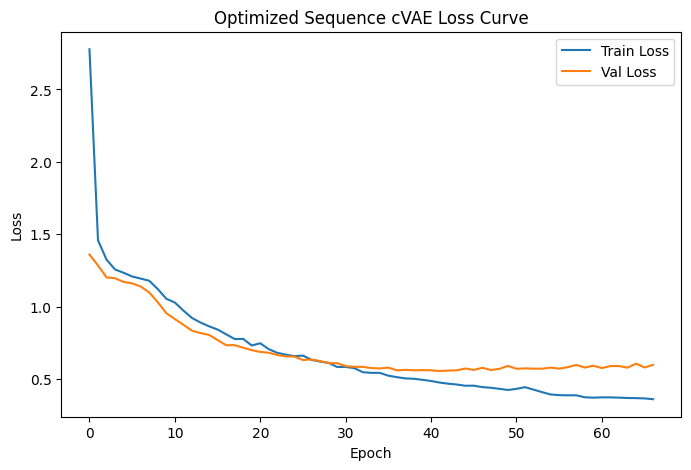

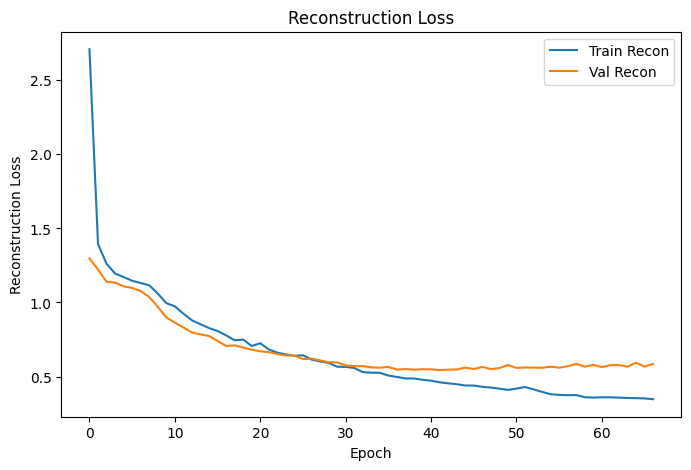

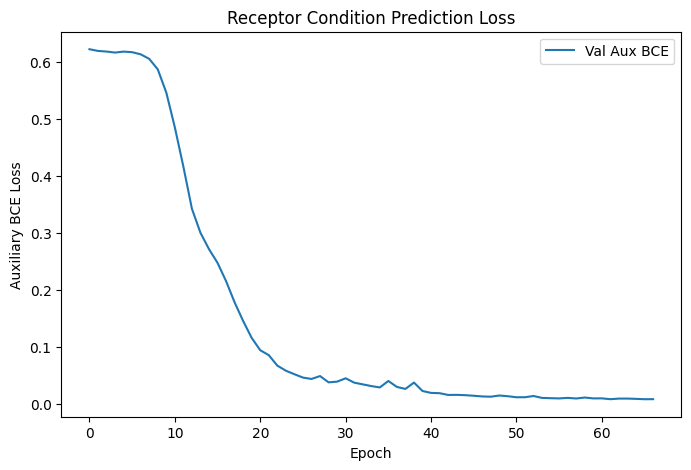

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Optimized Sequence cVAE Loss Curve")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["train_recon"], label="Train Recon")
plt.plot(history["val_recon"], label="Val Recon")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("Reconstruction Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["val_aux"], label="Val Aux BCE")
plt.xlabel("Epoch")
plt.ylabel("Auxiliary BCE Loss")
plt.title("Receptor Condition Prediction Loss")
plt.legend()
plt.show()


reconstruction -> metric : identity

In [ ]:
def sequence_identity(seq1, seq2):
    min_len = min(len(seq1), len(seq2))
    max_len_ = max(len(seq1), len(seq2))
    if max_len_ == 0:
        return 0.0
    matches = sum(seq1[i] == seq2[i] for i in range(min_len))
    return matches / max_len_


def reconstruct_all_cvae(model, val_df, stoi, itos, max_len, device):
    model.eval()
    rows = []
    val_df = val_df.reset_index(drop=True)

    with torch.no_grad():
        for i in range(len(val_df)):
            seq = val_df.loc[i, "sequence"]
            x = encode_sequence(seq, stoi, max_len).unsqueeze(0).to(device)
            c = val_df.loc[i, ["GLP1R", "GIPR", "GCGR"]].values.astype("float32")
            c_tensor = torch.tensor(c, dtype=torch.float32).unsqueeze(0).to(device)

            logits, mu, logvar, condition_logits = model(x, c_tensor)
            pred_ids = logits.argmax(dim=-1).squeeze(0).cpu()
            recon_seq = decode_sequence(pred_ids, itos)

            condition_pred = (torch.sigmoid(condition_logits).squeeze(0).cpu().numpy() >= 0.5).astype(int)

            rows.append({
                "original": seq,
                "reconstructed": recon_seq,
                "identity": sequence_identity(seq, recon_seq),
                "orig_len": len(seq),
                "recon_len": len(recon_seq),
                "length_diff": abs(len(seq) - len(recon_seq)),
                "exact_match": seq == recon_seq,
                "GLP1R": int(c[0]),
                "GIPR": int(c[1]),
                "GCGR": int(c[2]),
                "condition": f"{int(c[0])}{int(c[1])}{int(c[2])}",
                "pred_GLP1R": int(condition_pred[0]),
                "pred_GIPR": int(condition_pred[1]),
                "pred_GCGR": int(condition_pred[2]),
                "agonist_type": val_df.loc[i, "agonist_type"] if "agonist_type" in val_df.columns else None,
                "label": val_df.loc[i, "label"] if "label" in val_df.columns else None,
                "source": val_df.loc[i, "source"] if "source" in val_df.columns else None,
            })

    return pd.DataFrame(rows)


condition_result_df = reconstruct_all_cvae(model, val_df, stoi, itos, max_len, device)

overall_metrics = {
    "mean_identity_percent": condition_result_df["identity"].mean() * 100,
    "exact_match_rate_percent": condition_result_df["exact_match"].mean() * 100,
    "mean_length_diff": condition_result_df["length_diff"].mean(),
}

overall_metrics


# --- sanity check: condition column 오류 재발 방지 ---
assert condition_result_df["GCGR"].isin([0, 1]).all(), \
    "GCGR 열이 0/1이 아닙니다. reconstruct_all_cvae의 'GCGR' 값을 확인하세요."
_expected = (
    condition_result_df["GLP1R"].astype(str)
    + condition_result_df["GIPR"].astype(str)
    + condition_result_df["GCGR"].astype(str)
)
assert (_expected == condition_result_df["condition"]).all(), \
    "GLP1R/GIPR/GCGR 비트와 condition 문자열이 불일치합니다."
print("condition column sanity check passed.")


condition column sanity check passed.


In [ ]:
condition_result_df.head(10)


,original,reconstructed,identity,orig_len,recon_len,length_diff,exact_match,GLP1R,GIPR,GCGR,condition,pred_GLP1R,pred_GIPR,pred_GCGR,agonist_type,label,source
0,YSEGTFTSDYSKLKEEEANRLFIEWLLAGGPSSGAPPPS,HSEGTFTSDYSKYLDSEAAREFVAWLVAGGPSSGAPPPS,0.743590,39,39,0,False,1,0,1,101,1,0,1,dual,Peptide_Models,Peptide Models
1,HSQGTFTSDYSKFLDTRRAQDFVQWLMNT,HSQGTFTSDYSKYLDTRRAQDFVQWLMNT,0.965517,29,29,0,False,0,0,1,001,0,0,1,mono,Glucagon_ortholog,UniProt
2,YAEGTFISDYSIAMDKIRQQDFVNWLLAQKGKKNDWRHNLTQ,YAEGTFISDYSIAMDKIRQQDFVNWLLAQKGKKNDWKHNITQ,0.952381,42,42,0,False,0,1,0,010,0,1,0,mono,GIP_ortholog,NCBI_protein
3,HAEGTFTSDLSSYLEDQAVKEFIAWLVKGR,HAEGTFTSDVSSYLEGQAAKEFIAWLVKGR,0.900000,30,30,0,False,1,0,0,100,1,0,0,dual,GLP1_ortholog,NCBI_nuc
4,HADGTFTSDYNKLLDDMATQEFLKWLINSK,HADGTFTSDINKVLDDMAAKEFLKWLINTK,0.833333,30,30,0,False,1,0,0,100,1,0,0,dual,GLP1_ortholog,NCBI_nuc
5,HADGTFTSDYNKLLDDLATQEFLKWLINQK,HADGTFTSDINKVLDDMAAKEFLKWLINTK,0.800000,30,30,0,False,1,0,0,100,1,0,0,dual,GLP1_ortholog,UniProt
6,YAEGTIISDYRIILDKIRQQEFVNWLLAQKGKKNDWKHNITQ,YAEGTFISDYSIAMDKIRQQDFVNWLLAQKGKKNDWKHNITQ,0.880952,42,42,0,False,0,1,0,010,0,1,0,mono,GIP_ortholog,NCBI_protein
7,HAEGFTSDVSSYLEGQAAKEFIAWLVKGR,HAEGTFSDVSSYLEGQAAKEFIAWLVKGR,0.931034,29,29,0,False,1,0,1,101,1,0,1,dual,Peptide_Models,Peptide Models
8,HAEGTFTSDVSSYLEGQAAKEFAWLVKGR,HAEGTFTSDVSSYLEGQAAEFIAWLVKGR,0.896552,29,29,0,False,1,0,1,101,1,0,1,dual,Peptide_Models,Peptide Models
9,HXEGTFTSDVSSYLEGQAAKEFIAWLVRGRG,HAEGTFTSDVSSYLEGQAAKEFIAWLVKGR,0.903226,31,30,1,False,1,0,0,100,1,0,0,mono,Semaglutide,Milestone


condition-wise metrics

In [ ]:
condition_summary = (
    condition_result_df
    .groupby(["GLP1R", "GIPR", "GCGR", "condition"])
    .agg(
        count=("identity", "count"),
        mean_identity_percent=("identity", lambda x: x.mean() * 100),
        std_identity_percent=("identity", lambda x: x.std() * 100),
        exact_match_rate_percent=("exact_match", lambda x: x.mean() * 100),
        mean_length_diff=("length_diff", "mean"),
    )
    .reset_index()
)

for col in ["mean_identity_percent", "std_identity_percent", "exact_match_rate_percent", "mean_length_diff"]:
    condition_summary[col] = condition_summary[col].round(2)

condition_summary


,GLP1R,GIPR,GCGR,condition,count,mean_identity_percent,std_identity_percent,exact_match_rate_percent,mean_length_diff
0,0,0,1,001,15,87.82,8.23,0.00,0.00
1,0,1,0,010,17,93.70,4.90,0.00,0.00
2,1,0,0,100,33,85.88,9.21,0.00,0.06
3,1,0,1,101,26,79.79,23.65,3.85,1.92
4,1,1,0,110,1,76.67,NaN,0.00,1.00


In [ ]:
if "agonist_type" in condition_result_df.columns:
    agonist_summary = (
        condition_result_df
        .groupby("agonist_type")
        .agg(
            count=("identity", "count"),
            mean_identity_percent=("identity", lambda x: x.mean() * 100),
            std_identity_percent=("identity", lambda x: x.std() * 100),
            exact_match_rate_percent=("exact_match", lambda x: x.mean() * 100),
            mean_length_diff=("length_diff", "mean"),
        )
        .reset_index()
    )

    for col in ["mean_identity_percent", "std_identity_percent", "exact_match_rate_percent", "mean_length_diff"]:
        agonist_summary[col] = agonist_summary[col].round(2)

    display(agonist_summary)


,agonist_type,count,mean_identity_percent,std_identity_percent,exact_match_rate_percent,mean_length_diff
0,dual,56,82.40,17.48,1.79,0.91
1,mono,36,91.13,6.94,0.00,0.06


evaluation

In [ ]:
def multilabel_f1_per_label(y_true, y_pred):
    rows = []
    labels = ["GLP1R", "GIPR", "GCGR"]
    for i, lab in enumerate(labels):
        yt = y_true[:, i]
        yp = y_pred[:, i]
        tp = ((yt == 1) & (yp == 1)).sum()
        fp = ((yt == 0) & (yp == 1)).sum()
        fn = ((yt == 1) & (yp == 0)).sum()
        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)
        acc = (yt == yp).mean()
        rows.append({
            "target": lab,
            "accuracy": acc,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        })
    return pd.DataFrame(rows)


y_true = condition_result_df[["GLP1R", "GIPR", "GCGR"]].values.astype(int)
y_pred = condition_result_df[["pred_GLP1R", "pred_GIPR", "pred_GCGR"]].values.astype(int)

aux_eval = multilabel_f1_per_label(y_true, y_pred)
aux_eval


,target,accuracy,precision,recall,f1
0,GLP1R,0.98913,1.0,0.983333,0.991597
1,GIPR,0.98913,1.0,0.944444,0.971429
2,GCGR,1.00000,1.0,1.000000,1.000000


## condition swap test
같은 latent z에 condition만 바꿔서 output 달라지는지 확인
-> 거의 안달라지면 conditional control이 약한 것
-> condition별로 일부 motif/tail 달라지면 condition이 decoder에 영향 준 것.



In [ ]:
def condition_swap_test(model, seq, original_condition, conditions, stoi, itos, max_len, device):
    model.eval()
    outputs = []

    x = encode_sequence(seq, stoi, max_len).unsqueeze(0).to(device)
    original_c = torch.tensor([original_condition], dtype=torch.float32).to(device)

    with torch.no_grad():
        mu, logvar = model.encode(x, original_c)
        z = mu

        for cond in conditions:
            c = torch.tensor([cond], dtype=torch.float32).to(device)
            logits = model.decode(z, c)
            pred_ids = logits.argmax(dim=-1).squeeze(0).cpu()
            recon_seq = decode_sequence(pred_ids, itos)
            outputs.append((cond, recon_seq))

    return outputs


test_row = val_df.reset_index(drop=True).iloc[0]
test_seq = test_row["sequence"]
original_condition = test_row[["GLP1R", "GIPR", "GCGR"]].astype(float).values.tolist()

conditions_to_test = [
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1],
    [1, 0, 1],
    [1, 1, 0],
    [1, 1, 1],
]

swap_results = condition_swap_test(
    model, test_seq, original_condition, conditions_to_test, stoi, itos, max_len, device
)

print("Original sequence:", test_seq)
print("Original condition:", original_condition)
for cond, out in swap_results:
    print(cond, "=>", out)


Original sequence: YSEGTFTSDYSKLKEEEANRLFIEWLLAGGPSSGAPPPS
Original condition: [1.0, 0.0, 1.0]
[1, 0, 0] => HSEGTFTSDYSKYLEEEAAREFVAWLVKGG
[0, 1, 0] => HSEGTFTSDYSKYLDSEAAREFVQWLVAGGPSSGAPPPS
[0, 0, 1] => HSEGTFTSDYSKYLDSEAAREFVQWLVKGG
[1, 0, 1] => HSEGTFTSDYSKYLDSEAAREFVQWLVAGGPSSGAPPPS
[1, 1, 0] => HSEGTFTSDYSKYLDSEAAREFVQWLVAGGPSSGAPPPS
[1, 1, 1] => YSEGTFTSDYSKYLDSEAAREFVQWLVAGGPSSGAPPPS


protparam distribution comparison

In [ ]:
try:
    from Bio.SeqUtils.ProtParam import ProteinAnalysis
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "biopython"])
    from Bio.SeqUtils.ProtParam import ProteinAnalysis

STANDARD_AA = set("ACDEFGHIKLMNPQRSTVWY")

def is_standard_peptide(seq):
    return set(seq).issubset(STANDARD_AA) and len(seq) > 0

def protparam_features(seq):
    if not is_standard_peptide(seq):
        return None
    try:
        analysis = ProteinAnalysis(seq)
        return {
            "molecular_weight": analysis.molecular_weight(),
            "isoelectric_point": analysis.isoelectric_point(),
            "gravy": analysis.gravy(),
            "aromaticity": analysis.aromaticity(),
            "instability_index": analysis.instability_index(),
        }
    except Exception:
        return None


def build_protparam_df(result_df):
    rows = []
    for _, row in result_df.iterrows():
        for kind, seq_col in [("original", "original"), ("reconstructed", "reconstructed")]:
            feats = protparam_features(row[seq_col])
            if feats is None:
                continue
            feats.update({
                "kind": kind,
                "condition": row["condition"],
                "GLP1R": row["GLP1R"],
                "GIPR": row["GIPR"],
                "GCGR": row["GCGR"],
            })
            rows.append(feats)
    return pd.DataFrame(rows)

protparam_df = build_protparam_df(condition_result_df)
print(protparam_df.shape)
protparam_df.head()


(181, 10)


,molecular_weight,isoelectric_point,gravy,aromaticity,instability_index,kind,condition,GLP1R,GIPR,GCGR
0,4232.5688,4.420960,-0.610256,0.128205,69.228205,original,101,1,0,1
1,4072.3149,4.501842,-0.435897,0.128205,59.328205,reconstructed,101,1,0,1
2,3480.7741,6.749426,-0.844828,0.172414,37.562069,original,001,0,0,1
3,3496.7735,6.748516,-0.986207,0.172414,37.562069,reconstructed,001,0,0,1
4,5030.5885,8.343772,-0.857143,0.142857,29.090476,original,010,0,1,0


In [ ]:
protparam_summary = (
    protparam_df
    .groupby("kind")
    [["molecular_weight", "isoelectric_point", "gravy", "aromaticity", "instability_index"]]
    .agg(["mean", "std"])
)

protparam_summary


molecular_weight             isoelectric_point            \
                          mean         std              mean       std   
kind                                                                     
original           3784.736987  659.818945          5.988761  1.498501   
reconstructed      3717.995560  645.578941          6.324658  1.343263   

                  gravy           aromaticity           instability_index  \
                   mean       std        mean       std              mean   
kind                                                                        
original      -0.570599  0.312015    0.138756  0.024993         31.076721   
reconstructed -0.564115  0.310780    0.140452  0.025454         29.009908   

                          
                     std  
kind                      
original       16.700286  
reconstructed  14.056313

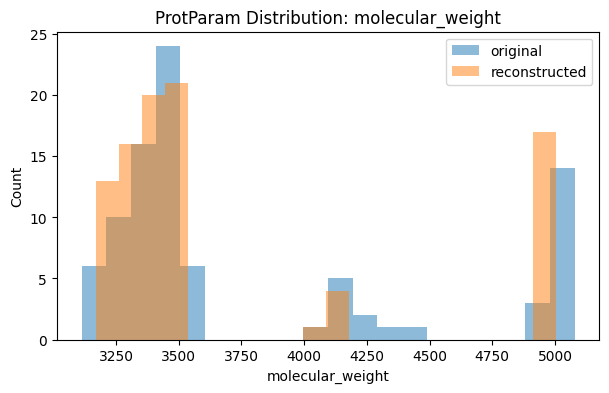

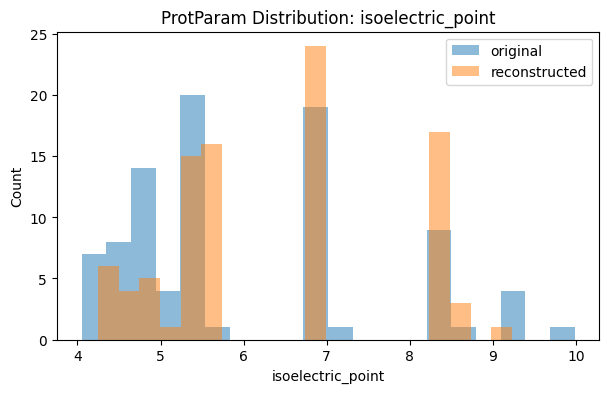

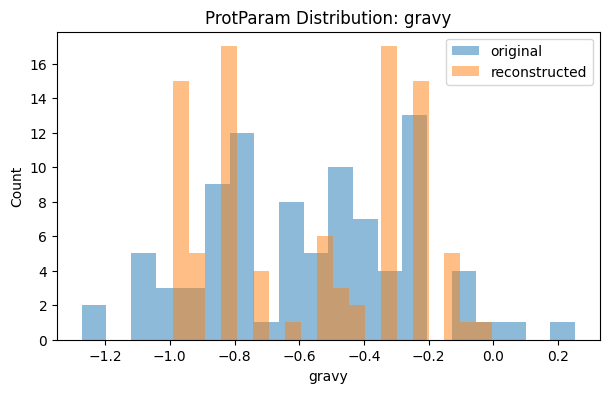

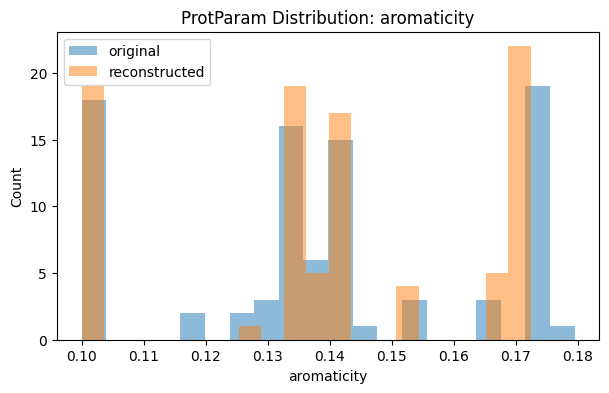

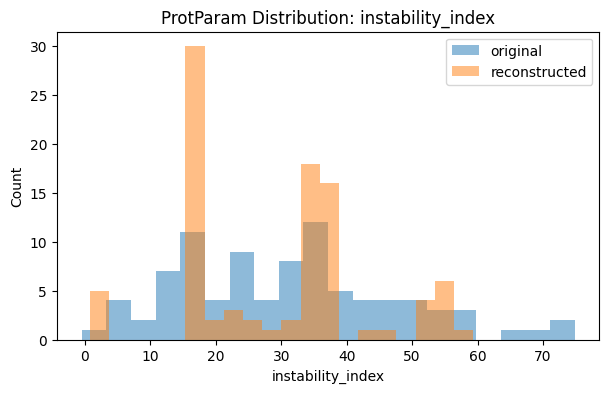

In [ ]:
properties = ["molecular_weight", "isoelectric_point", "gravy", "aromaticity", "instability_index"]
for prop in properties:
    plt.figure(figsize=(7, 4))
    for kind in ["original", "reconstructed"]:
        values = protparam_df.loc[protparam_df["kind"] == kind, prop].dropna()
        plt.hist(values, bins=20, alpha=0.5, label=kind)
    plt.xlabel(prop)
    plt.ylabel("Count")
    plt.title(f"ProtParam Distribution: {prop}")
    plt.legend()
    plt.show()


latent interpolation

In [ ]:
def encode_row_to_mu(model, row, stoi, max_len, device):
    seq = row["sequence"]
    x = encode_sequence(seq, stoi, max_len).unsqueeze(0).to(device)
    c = row[["GLP1R", "GIPR", "GCGR"]].astype(float).values.astype("float32")
    c = torch.tensor([c], dtype=torch.float32).to(device)
    with torch.no_grad():
        mu, logvar = model.encode(x, c)
    return mu, c


def interpolate_sequences(model, row_a, row_b, stoi, itos, max_len, device, steps=7, condition_mode="linear"):
    model.eval()
    z_a, c_a = encode_row_to_mu(model, row_a, stoi, max_len, device)
    z_b, c_b = encode_row_to_mu(model, row_b, stoi, max_len, device)

    outputs = []
    with torch.no_grad():
        for t in np.linspace(0, 1, steps):
            z = (1 - t) * z_a + t * z_b
            if condition_mode == "start":
                c = c_a
            elif condition_mode == "end":
                c = c_b
            else:
                c = (1 - t) * c_a + t * c_b

            logits = model.decode(z, c)
            pred_ids = logits.argmax(dim=-1).squeeze(0).cpu()
            seq = decode_sequence(pred_ids, itos)
            outputs.append((round(float(t), 2), c.squeeze(0).cpu().numpy(), seq))

    return outputs


val_reset = val_df.reset_index(drop=True)
row_a = val_reset.iloc[0]
row_b = val_reset.iloc[min(10, len(val_reset)-1)]

print("Start:", row_a["sequence"], row_a[["GLP1R", "GIPR", "GCGR"]].values)
print("End  :", row_b["sequence"], row_b[["GLP1R", "GIPR", "GCGR"]].values)
print()

interp_results = interpolate_sequences(
    model, row_a, row_b, stoi, itos, max_len, device, steps=7, condition_mode="linear"
)

for t, cond, seq in interp_results:
    print(f"t={t}, condition={np.round(cond, 2)}")
    print(seq)
    print()


Start: YSEGTFTSDYSKLKEEEANRLFIEWLLAGGPSSGAPPPS [np.int64(1) np.int64(0) np.int64(1)]
End  : HSQGTFTSDYSEYLDSRRASEFVQWLISE [np.int64(1) np.int64(0) np.int64(1)]

t=0.0, condition=[1. 0. 1.]
HSEGTFTSDYSKYLDSEAAREFVQWLVAGGPSSGAPPPS

t=0.17, condition=[1. 0. 1.]
HSQGTFTSDYSKYLDSEAAREFVQWLVAGG

t=0.33, condition=[1. 0. 1.]
HSQGTFTSDYSKYLDSEAARDFVQWLVAGG

t=0.5, condition=[1. 0. 1.]
HSQGTFTSDYSKYLDSERARDFVQWLVAGG

t=0.67, condition=[1. 0. 1.]
HSQGTFTSDYSKYLDSRRARDFVQWLVAGG

t=0.83, condition=[1. 0. 1.]
HSQGTFTSDYSKYLDSRRARDFVQWLVNG

t=1.0, condition=[1. 0. 1.]
HSQGTFTSDYSKYLDSRRAQDFVQWLVNG



/tmp/ipykernel_4543/3529961552.py:5: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  c = torch.tensor([c], dtype=torch.float32).to(device)


## Sequence Latent Space Interpolation (약물 진화 궤적 분석)

**단백질 서열(Sequence) 고유의 물리화학적 특성**을 활용하여 잠재 공간(Latent Space) 상의 연속성을 증명합니다.

단일 작용제(GLP-1) 벡터에서 다중 작용제(이중/삼중) 벡터 방향으로 7단계 선형 보간(Interpolation)을 수행하며, 모델이 단순한 텍스트 나열이 아닌 '생물학적 약물 진화 궤적'을 학습했는지 검증합니다.

**[핵심 분석 지표]**
1. **서열 길이 (Length):** 39자에서 29자 등으로 부드럽게 조절되는가?
2. **분자량 (MW) & 등전점 (pI):** 생성된 펩타이드의 물리화학적 수치가 목표 약물을 향해 점진적으로 수렴하는가?
3. **모티프 (Motif):** 각 수용체 고유의 아미노산이 단계별로 부드럽게 스왑(Swap)되는가?

In [ ]:
# 필요한 라이브러리 설치 (최초 1회만 주석 해제 후 실행)
# !pip install biopython

import torch
import numpy as np
import pandas as pd
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from IPython.display import display

# ==========================================
# 1. 데이터셋에서 실제 서열(Sequence) 문자열로 인덱스 찾기
# ==========================================
# 분석하고 싶은 실제 아미노산 서열 (위: Semaglutide, 아래: Retatrutide)
start_seq = "HXEGTFTSDVSSYLEGQAAKEFIAWLVRGRG"
end_seq = "YXQGTFTSDYSILLDKKAQXAFIEYLLEGGPSSGAPPPS"

try:
    # 데이터프레임(df)의 'sequence' 컬럼과 정확히 일치하는 행의 인덱스를 추출
    idx_A = df[df['sequence'] == start_seq].index[0]
    idx_B = df[df['sequence'] == end_seq].index[0]

    # 해당 서열의 라벨/소스 출력 (컬럼명 'label' 기준)
    name_A = df.loc[idx_A, 'label'] if 'label' in df.columns else "Start Drug"
    name_B = df.loc[idx_B, 'label'] if 'label' in df.columns else "End Drug"

    print(f"✅ 출발 서열 인덱스: {idx_A} (Label: {name_A})")
    print(f"✅ 도착 서열 인덱스: {idx_B} (Label: {name_B})")

except IndexError:
    print("❌ 데이터프레임에 일치하는 서열이 없습니다. 서열 문자열을 확인해주세요.")
    idx_A, idx_B = 0, len(df)-1

# ==========================================
# 2. DataFrame에서 직접 텐서로 변환 (오류 해결 파트!)
# ==========================================
row_A = df.loc[idx_A]
row_B = df.loc[idx_B]

tensor_A = encode_sequence(row_A['sequence'], stoi, max_len).unsqueeze(0).to(device)
tensor_B = encode_sequence(row_B['sequence'], stoi, max_len).unsqueeze(0).to(device)

# Condition 텐서 변환 (3-bit)
c_A = row_A[["GLP1R", "GIPR", "GCGR"]].astype(float).values.astype("float32")
c_B = row_B[["GLP1R", "GIPR", "GCGR"]].astype(float).values.astype("float32")

cond_A = torch.tensor([c_A], dtype=torch.float32).to(device)
cond_B = torch.tensor([c_B], dtype=torch.float32).to(device)

# 텍스트 변환 시 제외할 특수 토큰
ignore_tokens = [pad_idx, sos_idx, eos_idx]

model.eval()
with torch.no_grad():
    # 인코더를 통해 Latent Vector (mu) 추출
    mu_A, _ = model.encode(tensor_A, cond_A)
    mu_B, _ = model.encode(tensor_B, cond_B)

    # ==========================================
    # 3. 보간(Interpolation) 7단계 진행
    # ==========================================
    steps = 7
    alphas = np.linspace(0, 1, steps)
    results = []

    for alpha in alphas:
        # Latent Space 상에서 선형 이동
        z_interp = (1 - alpha) * mu_A + alpha * mu_B

        # Condition도 부드럽게 이동
        c_interp = (1 - alpha) * cond_A + alpha * cond_B

        # 디코딩
        logits = model.decode(z_interp, c_interp)
        pred_tensor = logits.argmax(dim=-1).squeeze(0).cpu().numpy()

        # 아미노산 문자열 변환 (연지님의 itos 딕셔너리 사용)
        seq_str = "".join([itos[int(t)] for t in pred_tensor if t not in ignore_tokens])

        # ==========================================
        # 4. Sequence 물리화학적 지표(ProtParam) 계산
        # ==========================================
        try:
            # 특수/미지 토큰('X', '-') 제거 후 분석
            clean_seq = seq_str.replace("X", "").replace("-", "")
            analysis = ProteinAnalysis(clean_seq)
            mw = analysis.molecular_weight()
            pi = analysis.isoelectric_point()
        except Exception:
            mw, pi = None, None

        results.append({
            "Alpha": f"{alpha:.2f}",
            "Generated Sequence": seq_str,
            "Length": len(seq_str),
            "MW (분자량)": f"{mw:.1f}" if mw else "N/A",
            "pI (등전점)": f"{pi:.2f}" if pi else "N/A"
        })
# ==========================================
# 5. 결과 시각화
# ==========================================
df_results = pd.DataFrame(results)
print(f"\n=== 🧬 약물 진화 궤적 시각화 ===")
display(df_results)



✅ 출발 서열 인덱스: 453 (Label: Semaglutide)
✅ 도착 서열 인덱스: 455 (Label: Retatrutide)

=== 🧬 약물 진화 궤적 시각화 ===


,Alpha,Generated Sequence,Length,MW (분자량),pI (등전점)
0,0.00,HAEGTFTSDVSSYLEGQAAKEFIAWLVKGRGAPPPSCGKKK,41,4349.9,8.99
1,0.17,HAEGTFTSDVSSYLEGQAAKEFIAWLVKGRGAPPPSGKKK,40,4246.7,9.31
2,0.33,HAEGTFTSDVSSYLEGQAAKEFIAWLVKGRGAPPPSGKK,39,4118.6,8.39
3,0.50,HAEGTFTSDVSSYLEGQAAKEFIAWLVKGRSGAPPPSGKK,40,4205.6,8.39
4,0.67,HAEGTFTSDVSSYLEGQAAKEFIAWLVKGRSSGAPPPSGKK,41,4292.7,8.39
5,0.83,YAEGTFTSDYSIYLEKQAAREFIAWLLAGGPSSGAPPPSGKK,42,4462.9,6.25
6,1.00,YAEGTFTSDYSIYLDKQAAREFVNWLLAGGPSSGAPPPSGKK,42,4477.9,6.21


## Latent space PCA 시각화

PCA로 latent z를 2D에 투영하고, receptor binding pattern(condition)으로 색칠한다.
함께 silhouette score와 kNN classifier 정확도를 정량 지표로 계산한다.

**참고**: agonist_type (mono/dual/triple)으로 묶으면 서로 다른 receptor pattern
(예: GLP1R only, GIPR only, GCGR only가 모두 mono로 합쳐짐)이 한 라벨이 되어
cluster가 뭉개진다. condition(3-bit) 기준이 latent의 실제 구조를 보여준다.

In [ ]:
def extract_latents(model, df_input, stoi, max_len, device):
    model.eval()
    rows = []
    df_input = df_input.reset_index(drop=True)

    with torch.no_grad():
        for i in range(len(df_input)):
            seq = df_input.loc[i, "sequence"]
            x = encode_sequence(seq, stoi, max_len).unsqueeze(0).to(device)
            c = df_input.loc[i, ["GLP1R", "GIPR", "GCGR"]].values.astype("float32")
            c_tensor = torch.tensor(c, dtype=torch.float32).unsqueeze(0).to(device)
            mu, logvar = model.encode(x, c_tensor)
            z = mu.squeeze(0).cpu().numpy()

            rows.append({
                **{f"z{i}": z[i] for i in range(len(z))},
                "condition": f"{int(c[0])}{int(c[1])}{int(c[2])}",
                "GLP1R": int(c[0]),
                "GIPR": int(c[1]),
                "GCGR": int(c[2]),
                "label": df_input.loc[i, "label"] if "label" in df_input.columns else None,
                "agonist_type": df_input.loc[i, "agonist_type"] if "agonist_type" in df_input.columns else None,
                "sequence": seq,
            })

    return pd.DataFrame(rows)


latent_df = extract_latents(model, df, stoi, max_len, device)
z_cols = [c for c in latent_df.columns if c.startswith("z")]

pca = PCA(n_components=2, random_state=SEED)
z_2d = pca.fit_transform(latent_df[z_cols].values)
latent_df["PC1"] = z_2d[:, 0]
latent_df["PC2"] = z_2d[:, 1]

print("PCA explained variance ratio:", pca.explained_variance_ratio_)
latent_df.head()


PCA explained variance ratio: [0.59576064 0.29666623]


,z0,z1,z2,z3,z4,z5,z6,z7,z8,z9,...,z31,condition,GLP1R,GIPR,GCGR,label,agonist_type,sequence,PC1,PC2
0,0.517598,2.148127,-0.413958,-0.137266,1.454870,0.444717,1.602488,-1.669603,-0.068845,1.219209,...,-2.123806,001,0,0,1,Glucagon_ortholog,mono,HSQGTFTSDYSKYLDSRRAQQFLKWLLNV,-2.491815,-5.101796
1,0.689981,2.384782,-0.386839,-0.334900,1.542026,0.202552,1.700718,-1.617684,-0.266412,1.354444,...,-2.042745,001,0,0,1,Glucagon_ortholog,mono,HSQGTFTSDYSKFLDTRRAQDFLDWLKNT,-2.867929,-5.135966
2,0.782579,2.963659,-0.434417,-0.348214,2.109976,0.371909,2.110080,-1.987359,0.084502,1.344950,...,-2.932718,001,0,0,1,Glucagon_ortholog,mono,HSQGTFTSDYSKYLDSRRAQDFVHWLMNT,-3.176293,-7.013194
3,0.739160,2.873142,-0.430450,-0.334150,2.050707,0.401737,2.050453,-1.986650,0.093589,1.339142,...,-2.898347,001,0,0,1,Glucagon_ortholog,mono,HSQGTFTSDYSKYLDSRRAQDFVQWLMNN,-3.104817,-6.872829
4,0.797246,3.115238,-0.580950,-0.357179,2.301383,0.335839,2.198327,-1.985980,0.288869,1.316337,...,-3.192122,001,0,0,1,Glucagon_ortholog,mono,HSQGTFTSDYSKYLDSRRAQDFVQWLMST,-2.839887,-7.485324


평가 대상 conditions: ['100', '101', '010', '001']
condition
100    164
101    131
010     82
001     74

Silhouette (condition): 0.335
kNN accuracy (condition, 5-fold): 0.980
[참고] Silhouette (agonist_type): -0.092


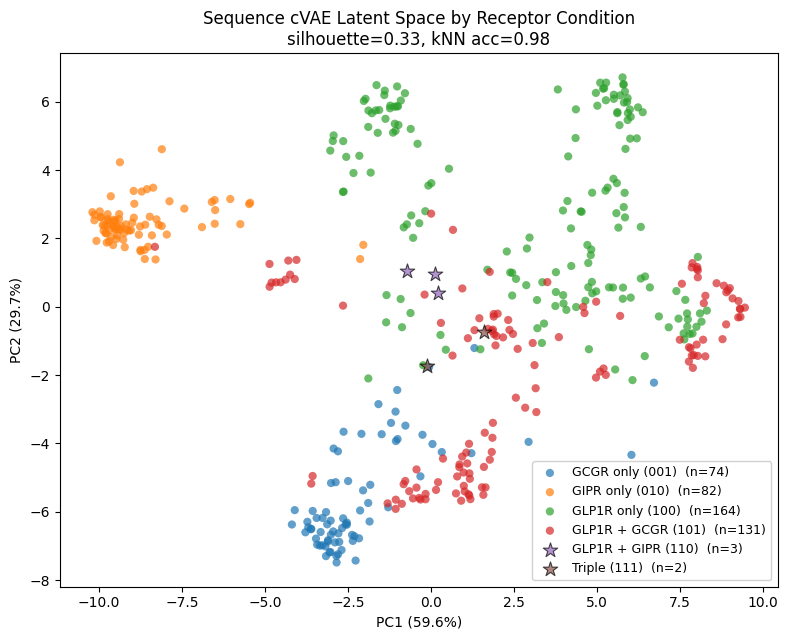

In [ ]:
# ===== PCA 시각화 + 정량 지표 =====
from sklearn.metrics import silhouette_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold

z_cols = [c for c in latent_df.columns if c.startswith("z")]
Z = latent_df[z_cols].values

# --- 정량 지표 (condition 기준) ---
# 샘플이 너무 적은 condition(110, 111)은 5-fold가 불가능하므로 평가에서 제외
condition_counts = latent_df["condition"].value_counts()
valid_conditions = condition_counts[condition_counts >= 5].index.tolist()
mask = latent_df["condition"].isin(valid_conditions)
Z_valid = Z[mask]
labels_valid = latent_df.loc[mask, "condition"].values

print(f"평가 대상 conditions: {valid_conditions}")
print(condition_counts[valid_conditions].to_string())
print()

sil_condition = silhouette_score(Z_valid, labels_valid)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
accs = []
for tr_idx, te_idx in skf.split(Z_valid, labels_valid):
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(Z_valid[tr_idx], labels_valid[tr_idx])
    accs.append(knn.score(Z_valid[te_idx], labels_valid[te_idx]))
knn_acc_condition = float(np.mean(accs))

print(f"Silhouette (condition): {sil_condition:.3f}")
print(f"kNN accuracy (condition, 5-fold): {knn_acc_condition:.3f}")
print(f"[참고] Silhouette (agonist_type): "
      f"{silhouette_score(Z, latent_df['agonist_type'].astype(str).values):.3f}")


# --- PCA 산점도 ---
condition_style = {
    "001": {"color": "#1f77b4", "label": "GCGR only (001)",     "marker": "o"},
    "010": {"color": "#ff7f0e", "label": "GIPR only (010)",     "marker": "o"},
    "100": {"color": "#2ca02c", "label": "GLP1R only (100)",    "marker": "o"},
    "101": {"color": "#d62728", "label": "GLP1R + GCGR (101)",  "marker": "o"},
    "110": {"color": "#9467bd", "label": "GLP1R + GIPR (110)",  "marker": "*"},
    "111": {"color": "#8c564b", "label": "Triple (111)",        "marker": "*"},
}

plt.figure(figsize=(8, 6.5))
for cond in ["001", "010", "100", "101", "110", "111"]:
    sub = latent_df[latent_df["condition"] == cond]
    if len(sub) == 0:
        continue
    style = condition_style[cond]
    size = 120 if cond in ["110", "111"] else 35   # 희소 class 강조
    edge = "black" if cond in ["110", "111"] else "none"
    plt.scatter(
        sub["PC1"], sub["PC2"],
        color=style["color"], label=f'{style["label"]}  (n={len(sub)})',
        alpha=0.7, s=size, marker=style["marker"],
        edgecolor=edge, linewidth=0.8,
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title(
    f"Sequence cVAE Latent Space by Receptor Condition\n"
    f"silhouette={sil_condition:.2f}, kNN acc={knn_acc_condition:.2f}"
)
plt.legend(loc="best", fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()


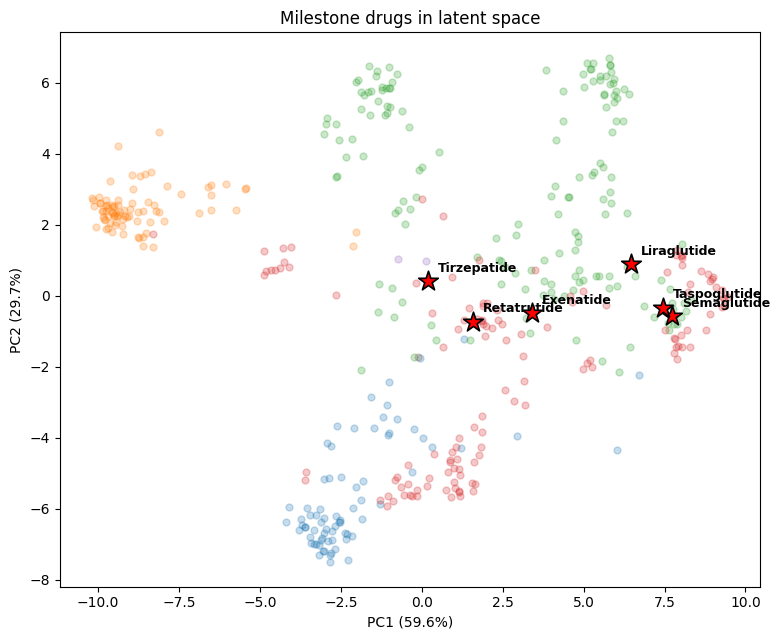

In [ ]:
# label 컬럼에 마일스톤 약물명이 들어 있을 경우 별표로 강조한다.
# 데이터에 해당 라벨이 없으면 그림만 동일하게 그려진다.

milestone_keywords = [
    "Semaglutide", "Tirzepatide", "Retatrutide",
    "Liraglutide", "Exenatide", "Taspoglutide"
]

plt.figure(figsize=(8, 6.5))

# 일반 점은 옅게 깔기
for cond in ["001", "010", "100", "101", "110", "111"]:
    sub = latent_df[latent_df["condition"] == cond]
    if len(sub) == 0:
        continue
    style = condition_style[cond]
    plt.scatter(sub["PC1"], sub["PC2"],
                color=style["color"], alpha=0.25, s=25)

# 마일스톤 강조
found_any = False
if "label" in latent_df.columns:
    for kw in milestone_keywords:
        m_mask = latent_df["label"].astype(str).str.contains(kw, case=False, na=False)
        if m_mask.sum() == 0:
            continue
        found_any = True
        for _, row in latent_df[m_mask].iterrows():
            plt.scatter(row["PC1"], row["PC2"],
                        color="red", s=220, marker="*",
                        edgecolor="black", linewidth=1.2, zorder=5)
            plt.annotate(kw, (row["PC1"], row["PC2"]),
                         fontsize=9, fontweight="bold",
                         xytext=(7, 7), textcoords="offset points")

if not found_any:
    print("label 컬럼에 마일스톤 약물명이 없어 강조 표시 없이 출력합니다.")

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("Milestone drugs in latent space")
plt.tight_layout()
plt.show()


결과 저장

In [ ]:
condition_result_df.to_csv("condition_reconstruction_results.csv", index=False)
condition_summary.to_csv("condition_summary.csv", index=False)
latent_df.to_csv("sequence_cvae_latent_pca.csv", index=False)

torch.save({
    "model_state_dict": model.state_dict(),
    "vocab": vocab,
    "stoi": stoi,
    "itos": itos,
    "max_len": max_len,
    "history": history,
    "config": {
        "embed_dim": 64,
        "hidden_dim": 128,
        "latent_dim": 32,
        "cond_hidden_dim": 32,
        "dropout": 0.2,
        "max_beta": max_beta,
        "aux_lambda": aux_lambda,
    }
}, "optimized_sequence_cvae.pt")

print("Saved:")
print("- condition_reconstruction_results.csv")
print("- condition_summary.csv")
print("- sequence_cvae_latent_pca.csv")
print("- optimized_sequence_cvae.pt")


Saved:
- condition_reconstruction_results.csv
- condition_summary.csv
- sequence_cvae_latent_pca.csv
- optimized_sequence_cvae.pt


## Checkpoint 저장

다음 노트북에서 모델을 다시 불러오기 위해 checkpoint를 저장합니다.

In [ ]:
# ============================================================
# Save checkpoint for generation / MSA notebook
# Colab Drive 자동 저장 버전
# ============================================================
import os

# Colab이면 Google Drive mount
try:
    BASE_DIR = "./sequences"
except Exception:
    # 로컬/일반 주피터 환경이면 현재 폴더에 저장
    BASE_DIR = "."

os.makedirs(BASE_DIR, exist_ok=True)
ckpt_path = os.path.join(BASE_DIR, "sequence_cvae_checkpoint.pt")

checkpoint = {
    "model_state_dict": model.state_dict(),
    "vocab": vocab,
    "max_len": max_len,
    "model_config": {
        "vocab_size": len(vocab),
        "max_len": max_len,
        "pad_idx": pad_idx,
        "condition_dim": 3,
        "embed_dim": 64,
        "hidden_dim": 128,
        "latent_dim": 32,
        "cond_hidden_dim": 32,
        "dropout": 0.2,
    },
    "best_val_loss": best_val_loss,
}

torch.save(checkpoint, ckpt_path)
print("Saved checkpoint:", ckpt_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved checkpoint: /content/drive/MyDrive/MLProject/Model/sequence_cvae_checkpoint.pt
